# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

data_candidates = [
    Path(r"C:\Machine_Learning_worksheet\Data\ames_housing.csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing.csv"),]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()

데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

- 상관관계의 방향과 강도는 어떠한가요?

r 값이 양수값이고 절대값이 0.71 이므로 비교적 강한 야으이 상관관계 

- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
p-value 가 0.05 보다 작으므로 상관계수가 0일것이라는 귀무가설을 기각한다.
즉 두변수는 통계적으로 유의 하다.

- $r^2$은 이 관계에서 무엇을 의미하나요?
-> 같은 자료에 생활면적을 설명변수로 하는 절편을 포함하여 최소 제곱 단순 선형회귀를 적합하여 결정계수 r^2 이 약 0.50 이다.
즉 생활면적을 이용한 직선 모형이 이 자료의 가격 변동을 약 50.2% 설명한다

- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?
아니다. 이미 존재하는 주택의 특성을 관찰한 데이터에서 다른 외부 요인 변수를 분리하여 확인 하지 못한다.


[0] 불러온 파일: C:\Machine_Learning_worksheet\Data\ames_housing.csv  (행 1460, 열 10)
    사용 컬럼: x=GrLivArea, y=SalePrice

[1] 결측치 제거
    GrLivArea 결측: 0개
    SalePrice 결측: 0개
    1460행 -> 1460행 (제거 0행)

[2] 피어슨 상관분석
    상관계수 r = 0.7086
    p-value   = 4.518e-223
    표본 크기 n = 1460, 자유도 = 1458

[3] 결정계수
    r^2 = 0.5021  (50.2%)



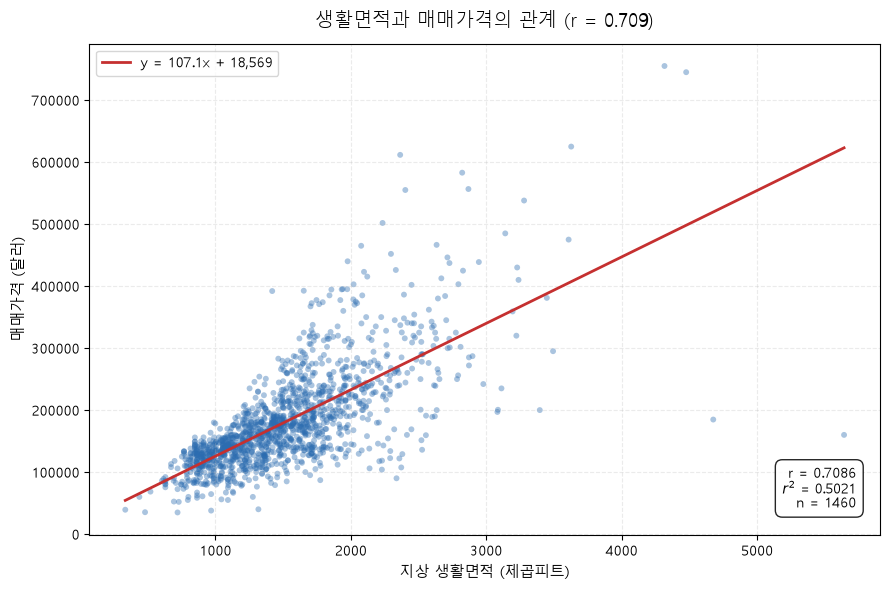

[4] 산점도 저장: scatter_grlivarea_saleprice.png

[5] 해석
    방향과 강도: 양의 상관관계, 강한 강도 (r = 0.7086)
    유의성: p-value(4.52e-223) < 0.05 이므로
            '모상관계수가 0이다'라는 귀무가설을 기각합니다.
            선형 상관관계가 통계적으로 유의합니다.
    설명력: 매매가격 분산의 50.2%를 생활면적이 설명하고,
            나머지 49.8%는 다른 요인에 의한 것입니다.
    기울기: 생활면적 1제곱피트 증가 시 가격이 평균 $107 높습니다.
            (단, 이는 연관성의 크기일 뿐 인과적 효과가 아닙니다.)

    [참고] 면적 4000 초과 & 가격 30만 미만인 관측치 2건:
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000
    이 관측치를 뺀 r = 0.7350 (원래 0.7086)


In [ ]:
# 여기에 코드를 작성하세요.
"""
생활면적(GrLivArea) 과 매매가격(SalePrice) 의 피어슨 상관분석
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy import stats

# ---------------------------------------------------------------
# 0. 데이터 불러오기
#    파일명이 train.csv / AmesHousing.csv 등으로 다를 수 있으므로
#    현재 폴더에서 후보를 찾아본다.
# ---------------------------------------------------------------



df = pd.read_csv(data_path)
print(f"[0] 불러온 파일: {data_path}  (행 {df.shape[0]}, 열 {df.shape[1]})")

# De Cock 원본은 컬럼명에 공백이 있음 ('Gr Liv Area')
x_col = "GrLivArea" if "GrLivArea" in df.columns else "Gr Liv Area"
y_col = "SalePrice"
print(f"    사용 컬럼: x={x_col}, y={y_col}\n")

# ---------------------------------------------------------------
# 1. 두 변수의 결측치를 제거한 분석용 데이터 만들기
# ---------------------------------------------------------------
data = df[[x_col, y_col]].dropna()

n_before = len(df)
n_after = len(data)

print("[1] 결측치 제거")
print(f"    {x_col} 결측: {df[x_col].isna().sum()}개")
print(f"    {y_col} 결측: {df[y_col].isna().sum()}개")
print(f"    {n_before}행 -> {n_after}행 (제거 {n_before - n_after}행)\n")

x = data[x_col]
y = data[y_col]

# ---------------------------------------------------------------
# 2. stats.pearsonr() 로 상관계수 r 과 p-value 계산
# ---------------------------------------------------------------
r, p_value = stats.pearsonr(x, y)

print("[2] 피어슨 상관분석")
print(f"    상관계수 r = {r:.4f}")
print(f"    p-value   = {p_value:.4g}")
print(f"    표본 크기 n = {n_after}, 자유도 = {n_after - 2}\n")

# ---------------------------------------------------------------
# 3. 결정계수 r^2 계산
# ---------------------------------------------------------------
r_squared = r ** 2

print("[3] 결정계수")
print(f"    r^2 = {r_squared:.4f}  ({r_squared:.1%})\n")

# ---------------------------------------------------------------
# 4. 축 이름과 제목이 있는 산점도
# ---------------------------------------------------------------
# 한글 폰트 설정 (없으면 영문 라벨로 대체)
korean_ok = False
for font_name in ["Malgun Gothic", "AppleGothic", "NanumGothic",
                  "NanumBarunGothic", "Noto Sans CJK KR"]:
    try:
        font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["axes.unicode_minus"] = False
        korean_ok = True
        break
    except Exception:
        continue

if korean_ok:
    title = f"생활면적과 매매가격의 관계 (r = {r:.3f})"
    xlabel = "지상 생활면적 (제곱피트)"
    ylabel = "매매가격 (달러)"
else:
    title = f"Living Area vs Sale Price (r = {r:.3f})"
    xlabel = "Above Ground Living Area (sq ft)"
    ylabel = "Sale Price (USD)"

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x, y, s=18, alpha=0.4, edgecolor="none", color="#2b6cb0")

# 추세선 (최소제곱 직선)
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept,
        color="#c53030", linewidth=2,
        label=f"y = {slope:,.1f}x + {intercept:,.0f}")

ax.set_title(title, fontsize=14, pad=12)
ax.set_xlabel(xlabel, fontsize=11)
ax.set_ylabel(ylabel, fontsize=11)
ax.legend(loc="upper left")
ax.grid(alpha=0.25, linestyle="--")

# r, r^2 를 그림 안에 표시
ax.text(0.97, 0.05,
        f"r = {r:.4f}\n$r^2$ = {r_squared:.4f}\nn = {n_after}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85))

plt.tight_layout()
plt.savefig("scatter_grlivarea_saleprice.png", dpi=150)
plt.show()

print("[4] 산점도 저장: scatter_grlivarea_saleprice.png\n")

# ---------------------------------------------------------------
# 5. 해석용 보조 수치
# ---------------------------------------------------------------
alpha = 0.05

if abs(r) >= 0.7:
    strength = "강한"
elif abs(r) >= 0.4:
    strength = "중간 정도의"
elif abs(r) >= 0.2:
    strength = "약한"
else:
    strength = "거의 없는 수준의"

direction = "양의" if r > 0 else "음의"

print("[5] 해석")
print(f"    방향과 강도: {direction} 상관관계, {strength} 강도 (r = {r:.4f})")

if p_value < alpha:
    print(f"    유의성: p-value({p_value:.3g}) < {alpha} 이므로")
    print("            '모상관계수가 0이다'라는 귀무가설을 기각합니다.")
    print("            선형 상관관계가 통계적으로 유의합니다.")
else:
    print(f"    유의성: p-value({p_value:.3g}) >= {alpha} 이므로")
    print("            선형 상관관계가 유의하다고 보기 어렵습니다.")

print(f"    설명력: 매매가격 분산의 {r_squared:.1%}를 생활면적이 설명하고,")
print(f"            나머지 {1 - r_squared:.1%}는 다른 요인에 의한 것입니다.")
print(f"    기울기: 생활면적 1제곱피트 증가 시 가격이 평균 ${slope:,.0f} 높습니다.")
print("            (단, 이는 연관성의 크기일 뿐 인과적 효과가 아닙니다.)")

# 이상치 참고: 면적이 매우 큰데 가격이 낮은 관측치
outliers = data[(data[x_col] > 4000) & (data[y_col] < 300000)]
if len(outliers) > 0:
    print(f"\n    [참고] 면적 4000 초과 & 가격 30만 미만인 관측치 {len(outliers)}건:")
    print(outliers.to_string(index=True))
    r_wo, p_wo = stats.pearsonr(
        data.drop(outliers.index)[x_col], data.drop(outliers.index)[y_col]
    )
    print(f"    이 관측치를 뺀 r = {r_wo:.4f} (원래 {r:.4f})")

---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
r 은 0.71 에서 0.26 으로 감소, p-value는 0.05 미만에서 0.06으로 증가 햇다.
귀무 가설을 기각함에 귀무가설을 기각할 수 없으로 판단이 변경

- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
요약 값만 보면 변화의 원인을 한 눈에 파악하기 어려움
산점도는 멀리 떨어진 점들과 일부 선형관계를 한 눈에 파악하기 쉬움
이 점은 이상치도 한눈에 파악 하기 쉽다는 것을 알려줌

- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
피어슨 r 은 직선 형태의 관계를 요약함
u자 형 그래프의 왼쪽과 오른쪽은 서류 반대 방향의 선형 움직임을 보이기 때문에 0에 가까움

- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?
아니다. r = 0 은 선형관계가 거의 없다는 뜻, 비선형 관계는 존재 할 수 있다.


A. 이상치의 영향
[A-1] 표본 추출: 50행 (random_state=42)
      GrLivArea  범위 630 ~ 3,086
      SalePrice  범위 75,500 ~ 451,950

[A-2] 이상치 추가 전
      r        = 0.7059
      r^2      = 0.4984
      p-value  = 1.026e-08
      유의성   = 유의함

[A-3] 가상 이상치 추가: GrLivArea=6000, SalePrice=50000
      표본 크기 50 -> 51
      원본 df 행 수: 1460 (변경 없음)

[A-4] 이상치 추가 후
      r        = 0.2602
      r^2      = 0.0677
      p-value  = 0.06514
      유의성   = 유의하지 않음

      [비교]
      r       : +0.7059  ->  +0.2602  (변화 -0.4457)
      r^2     : 0.4984  ->  0.0677
      p-value : 1.026e-08  ->  0.06514
      판단    : 유의함  ->  유의하지 않음
      ** 단 1개 관측치로 통계적 결론이 뒤집혔습니다 **



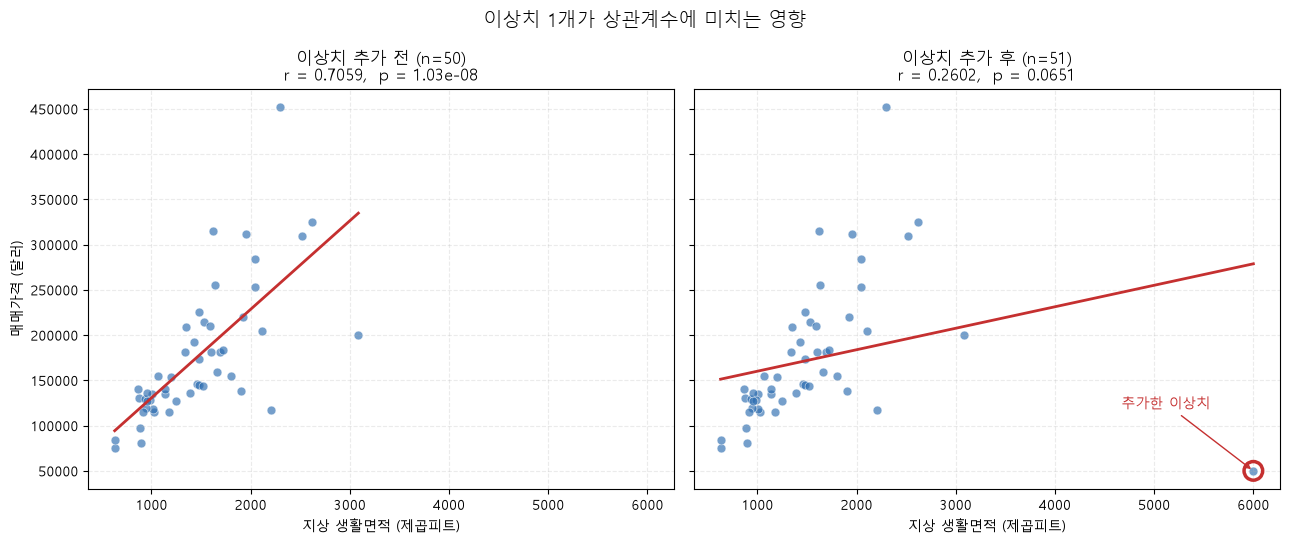

[A-5] 산점도 저장: A_outlier_effect.png

B. 비선형 관계
[B-1] 데이터
      x = [-3, -2, -1, 0, 1, 2, 3]
      y = [9, 4, 1, 0, 1, 4, 9]

[B-2] 피어슨 상관분석
      r       = 0.0000
      p-value = 1.0000
      유의성  = 유의하지 않음
      y = x^2 라는 완벽한 결정적 관계인데도 r = 0 입니다.

      [참고] 스피어만 rho = 0.0000 (p = 1.0000)  -> 단조관계가 아니라 이것도 0
      [참고] |x| 와 y 의 r = 0.9608  -> 변수를 바꾸면 관계가 드러남



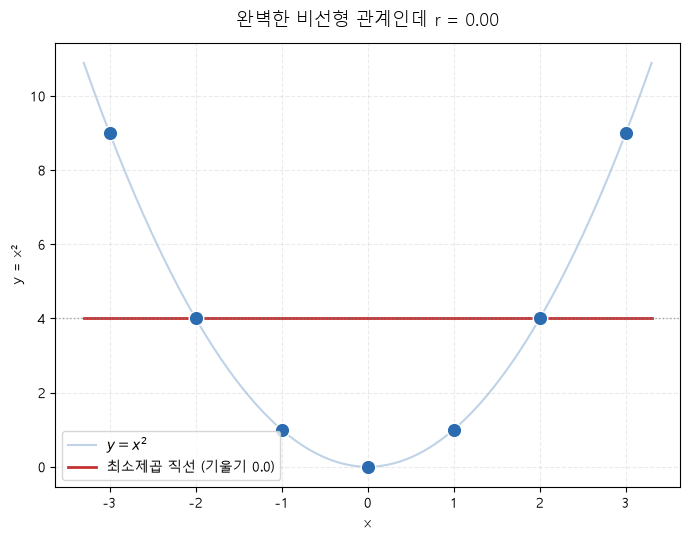

[B-2] 산점도 저장: B_nonlinear.png


In [5]:
# 여기에 코드를 작성하세요.
"""
A. 이상치가 피어슨 상관계수에 미치는 영향
B. 비선형 관계에서 피어슨 상관계수의 한계
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy import stats

# ---------------------------------------------------------------
# 한글 폰트 설정 (없으면 영문 라벨 사용)
# ---------------------------------------------------------------
KOREAN_OK = False
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
           "NanumBarunGothic", "Noto Sans CJK KR"]:
    try:
        font_manager.findfont(_f, fallback_to_default=False)
        plt.rcParams["font.family"] = _f
        plt.rcParams["axes.unicode_minus"] = False
        KOREAN_OK = True
        break
    except Exception:
        continue


def L(ko, en):
    """한글 폰트가 있으면 ko, 없으면 en 반환"""
    return ko if KOREAN_OK else en


# ---------------------------------------------------------------
# 데이터 불러오기
# ---------------------------------------------------------------
data_candidates = [
    Path(r"C:\Machine_Learning_worksheet\Data\ames_housing.csv"),
    Path("ames_housing.csv"),
    Path("train.csv"),
]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("ames_housing CSV 경로를 확인하세요.")

df = pd.read_csv(data_path)
df.columns = df.columns.str.replace(" ", "", regex=False)   # 공백 컬럼명 대응
alpha = 0.05

print("=" * 62)
print("A. 이상치의 영향")
print("=" * 62)

# ---------------------------------------------------------------
# A-1. random_state=42 로 50행 표본 추출
# ---------------------------------------------------------------
sample = df[["GrLivArea", "SalePrice"]].dropna().sample(n=50, random_state=42)

print(f"[A-1] 표본 추출: {len(sample)}행 (random_state=42)")
print(f"      GrLivArea  범위 {sample['GrLivArea'].min():,} ~ "
      f"{sample['GrLivArea'].max():,}")
print(f"      SalePrice  범위 {sample['SalePrice'].min():,} ~ "
      f"{sample['SalePrice'].max():,}\n")

# ---------------------------------------------------------------
# A-2. 표본의 r 과 p-value
# ---------------------------------------------------------------
r_before, p_before = stats.pearsonr(sample["GrLivArea"], sample["SalePrice"])

print("[A-2] 이상치 추가 전")
print(f"      r        = {r_before:.4f}")
print(f"      r^2      = {r_before ** 2:.4f}")
print(f"      p-value  = {p_before:.4g}")
print(f"      유의성   = {'유의함' if p_before < alpha else '유의하지 않음'}\n")

# ---------------------------------------------------------------
# A-3. 가상 이상치를 '표본에만' 추가 (원본 df 는 그대로)
# ---------------------------------------------------------------
outlier = pd.DataFrame({"GrLivArea": [6000], "SalePrice": [50000]},
                       index=["outlier"])
sample_with = pd.concat([sample, outlier])

print("[A-3] 가상 이상치 추가: GrLivArea=6000, SalePrice=50000")
print(f"      표본 크기 {len(sample)} -> {len(sample_with)}")
print(f"      원본 df 행 수: {len(df)} (변경 없음)\n")

# ---------------------------------------------------------------
# A-4. 이상치 추가 후 r 과 p-value
# ---------------------------------------------------------------
r_after, p_after = stats.pearsonr(sample_with["GrLivArea"],
                                  sample_with["SalePrice"])

print("[A-4] 이상치 추가 후")
print(f"      r        = {r_after:.4f}")
print(f"      r^2      = {r_after ** 2:.4f}")
print(f"      p-value  = {p_after:.4g}")
print(f"      유의성   = {'유의함' if p_after < alpha else '유의하지 않음'}\n")

print("      [비교]")
print(f"      r       : {r_before:+.4f}  ->  {r_after:+.4f}  "
      f"(변화 {r_after - r_before:+.4f})")
print(f"      r^2     : {r_before ** 2:.4f}  ->  {r_after ** 2:.4f}")
print(f"      p-value : {p_before:.4g}  ->  {p_after:.4g}")
verdict_b = "유의함" if p_before < alpha else "유의하지 않음"
verdict_a = "유의함" if p_after < alpha else "유의하지 않음"
print(f"      판단    : {verdict_b}  ->  {verdict_a}")
if (p_before < alpha) != (p_after < alpha):
    print("      ** 단 1개 관측치로 통계적 결론이 뒤집혔습니다 **")
print()

# ---------------------------------------------------------------
# A-5. 추가 전후 산점도를 나란히
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)

for ax, (xs, ys, r_, p_, ttl) in zip(axes, [
    (sample["GrLivArea"], sample["SalePrice"], r_before, p_before,
     L("이상치 추가 전 (n=50)", "Before outlier (n=50)")),
    (sample_with["GrLivArea"], sample_with["SalePrice"], r_after, p_after,
     L("이상치 추가 후 (n=51)", "After outlier (n=51)")),
]):
    ax.scatter(xs, ys, s=40, alpha=0.65, color="#2b6cb0",
               edgecolor="white", linewidth=0.5)
    slope, intercept = np.polyfit(xs, ys, 1)
    xl = np.linspace(xs.min(), xs.max(), 100)
    ax.plot(xl, slope * xl + intercept, color="#c53030", linewidth=2)
    ax.set_title(f"{ttl}\nr = {r_:.4f},  p = {p_:.3g}", fontsize=12)
    ax.set_xlabel(L("지상 생활면적 (제곱피트)", "Living Area (sq ft)"))
    ax.grid(alpha=0.25, linestyle="--")

axes[0].set_ylabel(L("매매가격 (달러)", "Sale Price (USD)"))

# 이상치 강조
axes[1].scatter([6000], [50000], s=180, facecolor="none",
                edgecolor="#c53030", linewidth=2.5, zorder=5)
axes[1].annotate(L("추가한 이상치", "added outlier"), xy=(6000, 50000),
                 xytext=(-95, 45), textcoords="offset points", color="#c53030",
                 fontsize=10, arrowprops=dict(arrowstyle="->", color="#c53030"))

fig.suptitle(L("이상치 1개가 상관계수에 미치는 영향",
               "Effect of a single outlier on Pearson r"), fontsize=14)
plt.tight_layout()
plt.savefig("A_outlier_effect.png", dpi=150)
plt.show()
print("[A-5] 산점도 저장: A_outlier_effect.png\n")

# ---------------------------------------------------------------
# B. 비선형 관계
# ---------------------------------------------------------------
print("=" * 62)
print("B. 비선형 관계")
print("=" * 62)

# B-1. x, y 만들기
x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = x ** 2

print("[B-1] 데이터")
print(f"      x = {x.tolist()}")
print(f"      y = {y.tolist()}\n")

# B-2. r 과 p-value
r_nl, p_nl = stats.pearsonr(x, y)

print("[B-2] 피어슨 상관분석")
print(f"      r       = {r_nl:.4f}")
print(f"      p-value = {p_nl:.4f}")
print(f"      유의성  = {'유의함' if p_nl < alpha else '유의하지 않음'}")
print("      y = x^2 라는 완벽한 결정적 관계인데도 r = 0 입니다.\n")

# 참고: 순위상관(스피어만)도 잡아내지 못함 / 단조변환 후에는 완벽
rho, p_rho = stats.spearmanr(x, y)
r_abs, p_abs = stats.pearsonr(np.abs(x), y)
print(f"      [참고] 스피어만 rho = {rho:.4f} (p = {p_rho:.4f})  "
      "-> 단조관계가 아니라 이것도 0")
print(f"      [참고] |x| 와 y 의 r = {r_abs:.4f}  "
      "-> 변수를 바꾸면 관계가 드러남\n")

# B-2. 산점도
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(x, y, s=110, color="#2b6cb0", edgecolor="white",
           linewidth=1, zorder=3)

xs = np.linspace(-3.3, 3.3, 200)
ax.plot(xs, xs ** 2, color="#2b6cb0", alpha=0.3, linewidth=1.5,
        linestyle="-", zorder=1, label="$y = x^2$")

slope, intercept = np.polyfit(x, y, 1)
ax.plot(xs, slope * xs + intercept, color="#c53030", linewidth=2,
        zorder=2, label=L(f"최소제곱 직선 (기울기 {slope:.1f})",
                          f"least-squares line (slope {slope:.1f})"))

ax.set_title(L(f"완벽한 비선형 관계인데 r = {r_nl:.2f}",
               f"Perfect nonlinear relation, yet r = {r_nl:.2f}"),
             fontsize=13, pad=12)
ax.set_xlabel("x")
ax.set_ylabel("y = x²" if KOREAN_OK else "y = x^2")
ax.axhline(y.mean(), color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax.legend()
ax.grid(alpha=0.25, linestyle="--")

plt.tight_layout()
plt.savefig("B_nonlinear.png", dpi=150)
plt.show()
print("[B-2] 산점도 저장: B_nonlinear.png")

---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요?
- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.

In [ ]:
# 여기에 코드를 작성하세요.


---

## 실습 마무리

- 어떤 문제가 있었는가?
상관 계수의 p-value 만으로는 관계를 명확하게 규정하기 어려움


- 어떻게 개선했는가?

- 무엇을 근거로 개선되었다고 판단했는가?
이상치 값 하나로 r 값과 p-value 가 달라지는 것을 확인했다.
본 데이터의 이상치를 제거한다면 정상적인 r 값과 p-value 로 올바른 통계적 해석이 가능하다.


피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.

